# LAPTOP PRICE PREDICTION MODEL

## Importing the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
sns.set()

## Loading the preprocessed data

In [2]:
Preprocessed_data = pd.read_csv('data_preprocessed.csv')
data=Preprocessed_data.copy()
data.head()

,RAM,Storage,Processor_Speed,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,Brand_Samsung,Condition_Refurbished,Condition_Used,log_price
0,16.0,256.0,3.72,0,0,0,0,0,1,0,0,0,7.198520
1,16.0,512.0,2.05,0,1,0,0,0,0,0,0,1,6.826556
2,4.0,2048.0,3.36,0,0,0,0,0,0,0,0,1,7.171119
3,8.0,256.0,2.81,0,0,0,0,0,1,0,0,0,6.921915
4,16.0,1024.0,3.50,0,0,0,0,0,0,1,0,0,7.404900


# Linear regression model

## Declare the inputs and the targets

In [3]:
y = data['log_price']
x = data.drop(['log_price'],axis=1)

In [4]:
x.head()

,RAM,Storage,Processor_Speed,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,Brand_Samsung,Condition_Refurbished,Condition_Used
0,16.0,256.0,3.72,0,0,0,0,0,1,0,0,0
1,16.0,512.0,2.05,0,1,0,0,0,0,0,0,1
2,4.0,2048.0,3.36,0,0,0,0,0,0,0,0,1
3,8.0,256.0,2.81,0,0,0,0,0,1,0,0,0
4,16.0,1024.0,3.50,0,0,0,0,0,0,1,0,0


In [5]:
# declare 4 variables for the split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)

In [6]:
# check the shape of the train inputs and targets
print (x_train.shape, y_train.shape)
print (x_test.shape, y_test.shape)

(768, 12) (768,)
(193, 12) (193,)


In [7]:
# Scaling input variables

In [8]:
scaler = StandardScaler()

In [9]:
scaler.fit(x_train)

StandardScaler()

In [10]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Create the regression

In [11]:
reg = LinearRegression()
reg.fit(x_train_scaled,y_train)

LinearRegression()

In [12]:
y_pred = reg.predict(x_train_scaled)

In [13]:
y_pred_test = reg.predict(x_test_scaled)

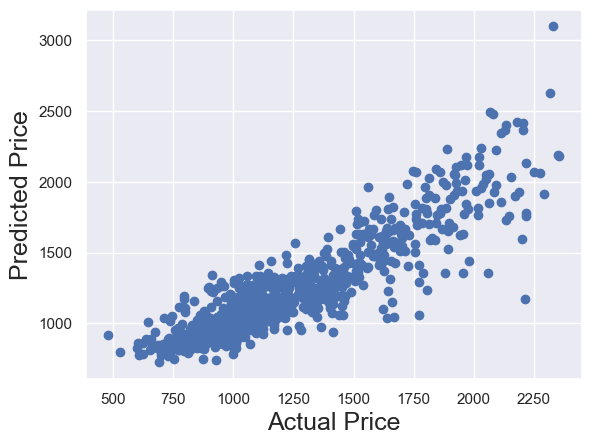

In [14]:
train_pred_price = np.exp(y_pred)
train_actual_price = np.exp(y_train)
plt.scatter(train_actual_price, train_pred_price)
plt.xlabel('Actual Price',size=18)
plt.ylabel('Predicted Price',size=18)
plt.show()

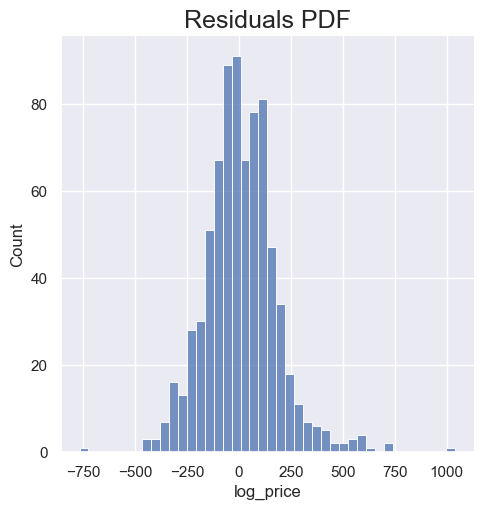

In [15]:
sns.displot(train_actual_price - train_pred_price)
plt.title("Residuals PDF", size=18)
plt.show()

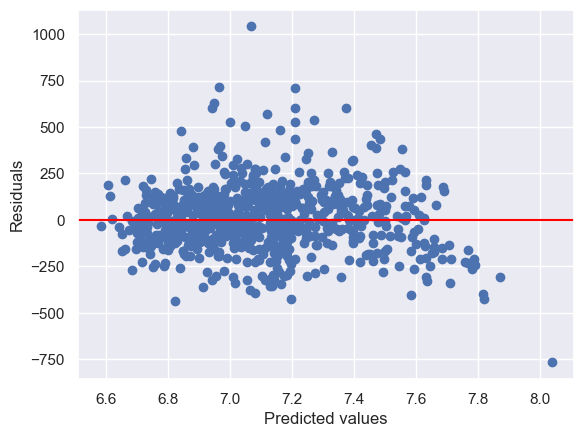

In [16]:
plt.scatter(reg.predict(x_train_scaled), train_actual_price - train_pred_price)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()

## Testing

In [17]:
test_pred_price = np.exp(y_pred_test)
test_actual_price = np.exp(y_test)

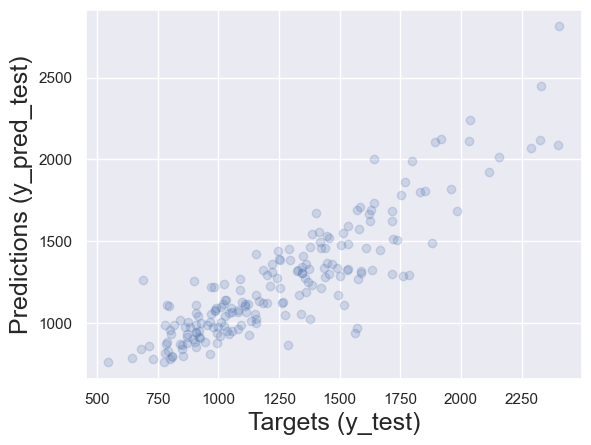

In [18]:
plt.scatter(test_actual_price, test_pred_price, alpha=0.2)
plt.xlabel('Targets (y_test)',size=18)
plt.ylabel('Predictions (y_pred_test)',size=18)
plt.show()

In [19]:
df_pf = pd.DataFrame(np.exp(y_pred_test), columns=['Prediction'])
df_pf.head()

,Prediction
0,1329.822674
1,1269.825098
2,1508.155515
3,1089.347950
4,1123.947200


In [20]:
df_pf['Target'] = np.exp(y_test)
df_pf

,Prediction,Target
0,1329.822674,NaN
1,1269.825098,922.01
2,1508.155515,NaN
3,1089.347950,NaN
4,1123.947200,NaN
...,...,...
188,775.170364,NaN
189,796.426505,788.57
190,939.922062,NaN
191,869.544647,NaN


In [21]:
y_test = y_test.reset_index(drop=True)
y_test.head()

0    7.225678
1    7.362544
2    7.458797
3    6.959531
4    7.000708
Name: log_price, dtype: float64

In [22]:
df_pf['Target'] = np.exp(y_test)
df_pf

,Prediction,Target
0,1329.822674,1374.27
1,1269.825098,1575.84
2,1508.155515,1735.06
3,1089.347950,1053.14
4,1123.947200,1097.41
...,...,...
188,775.170364,730.59
189,796.426505,810.43
190,939.922062,908.59
191,869.544647,843.13


In [23]:
df_pf['Residual'] = df_pf['Target'] - df_pf['Prediction']

In [24]:
df_pf['Difference%'] = np.absolute(df_pf['Residual']/df_pf['Target']*100)
df_pf

,Prediction,Target,Residual,Difference%
0,1329.822674,1374.27,44.447326,3.234250
1,1269.825098,1575.84,306.014902,19.419161
2,1508.155515,1735.06,226.904485,13.077616
3,1089.347950,1053.14,-36.207950,3.438095
4,1123.947200,1097.41,-26.537200,2.418166
...,...,...,...,...
188,775.170364,730.59,-44.580364,6.101967
189,796.426505,810.43,14.003495,1.727909
190,939.922062,908.59,-31.332062,3.448427
191,869.544647,843.13,-26.414647,3.132927


In [25]:
df_pf.describe()

,Prediction,Target,Residual,Difference%
count,193.000000,193.000000,193.000000,193.000000
mean,1248.706018,1262.109067,13.403049,10.586089
std,358.085280,382.552334,177.736476,10.206436
min,756.770488,546.130000,-570.667348,0.079738
25%,983.950966,967.080000,-92.539411,3.409151
50%,1171.196483,1202.090000,1.295753,8.681567
75%,1419.014543,1507.330000,109.019811,13.502690
max,2812.786892,2405.370000,630.813612,82.919321


In [26]:
pd.options.display.max_rows = 999
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_pf.sort_values(by=['Difference%'])

,Prediction,Target,Residual,Difference%
172,1623.72,1625.02,1.30,0.08
125,1357.80,1360.71,2.91,0.21
112,1076.37,1079.42,3.05,0.28
7,1572.83,1578.17,5.34,0.34
8,1113.74,1109.81,-3.93,0.35
175,972.49,976.66,4.17,0.43
137,1322.05,1328.01,5.96,0.45
169,1340.44,1346.52,6.08,0.45
31,1316.14,1323.53,7.39,0.56
70,1116.36,1123.01,6.65,0.59


# Finding the R squared, Adjusted R squared, weights and bias

In [27]:
reg.intercept_

7.105028671858666

In [28]:
reg.coef_

array([ 1.63509852e-01,  1.15995435e-01,  5.86135557e-02,  1.10555230e-01,
       -1.00466060e-02,  1.16131137e-02, -1.02775734e-02,  4.55262622e-03,
       -7.01813328e-04, -6.87275288e-05, -6.16105144e-02, -1.42294987e-01])

In [29]:
reg_summary = pd.DataFrame(x.columns.values, columns=['Features'])
reg_summary['Weights'] = reg.coef_
reg_summary

,Features,Weights
0,RAM,0.16
1,Storage,0.12
2,Processor_Speed,0.06
3,Brand_Apple,0.11
4,Brand_Asus,-0.01
5,Brand_Dell,0.01
6,Brand_HP,-0.01
7,Brand_Lenovo,0.00
8,Brand_MSI,-0.00
9,Brand_Samsung,-0.00


In [30]:
# R Squared Score
reg.score(x_train_scaled,y_train)

0.7745568787142332

In [31]:
reg.score(x_test_scaled,y_test)

0.7632941981777722

In [32]:
# Adjusted R Squared Score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_test)

n = x_test_scaled.shape[0]
p = x_test_scaled.shape[1]

adj_r2 = 1 - (1 - r2)*(n - 1)/(n - p - 1)

print(adj_r2)

0.7475138113896237
